In [1]:
import os
import sys
import django
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pickle
from sklearn.preprocessing import MinMaxScaler


In [2]:
sys.path.insert(0, r'C:\Users\rwenc\Documents\SSMI\medical_system')
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'medical_system.settings')
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

django.setup()
print("Django configuré !")

Django configuré !


In [3]:
from apps.dossiers.models import DossierMedical
from django.db.models import Count
from django.db.models.functions import TruncDate

# Extraire le Paludisme jour par jour
serie = DossierMedical.objects.filter(
    diagnostic='Paludisme'
).annotate(
    date=TruncDate('date_consultation')
).values('date').annotate(
    nombre=Count('id')
).order_by('date')

# Convertir en DataFrame
df = pd.DataFrame(list(serie))
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Remplir jours manquants
df = df.resample('D').sum()
df['nombre'] = df['nombre'].astype(float)
df['nombre'] = df['nombre'].replace(0, float('nan')).interpolate(method='linear')
df['nombre'] = df['nombre'].round().astype(int)

print(f"Données extraites : {len(df)} jours")
print(df.tail(5))

Données extraites : 180 jours
            nombre
date              
2026-03-26       7
2026-03-27       7
2026-03-28       7
2026-03-29       8
2026-03-30       7


In [4]:
print(df.head(5))
print(f"\nPériode complète : {df.index[0]} → {df.index[-1]}")

            nombre
date              
2025-10-02       7
2025-10-03       8
2025-10-04       7
2025-10-05       7
2025-10-06       8

Période complète : 2025-10-02 00:00:00 → 2026-03-30 00:00:00


In [5]:
# ── Définition du LSTM ────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                           num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# ── Définition du TimeGAN Générateur ─────────────────────
class Generateur(nn.Module):
    def __init__(self, bruit_dim=32, hidden_size=64, seq_len=7):
        super(Generateur, self).__init__()
        self.seq_len = seq_len
        self.fc_entree = nn.Linear(bruit_dim, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size,
                           num_layers=2, batch_first=True)
        self.fc_sortie = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, bruit):
        x = self.fc_entree(bruit)
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, _ = self.lstm(x)
        x = self.fc_sortie(x)
        return self.sigmoid(x)

# ── Charger les modèles ───────────────────────────────────
base_dir = r'C:\Users\rwenc\Documents\SSMI\medical_system'

# LSTM
lstm_model = LSTMModel()
lstm_model.load_state_dict(torch.load(
    os.path.join(base_dir, 'models', 'lstm_paludisme.pth'),
    map_location='cpu'
))
lstm_model.eval()

with open(os.path.join(base_dir, 'models', 'scaler_lstm.pkl'), 'rb') as f:
    scaler_lstm = pickle.load(f)

# TimeGAN
generateur = Generateur()
generateur.load_state_dict(torch.load(
    os.path.join(base_dir, 'models', 'timegan_generateur.pth'),
    map_location='cpu'
))
generateur.eval()

with open(os.path.join(base_dir, 'models', 'scalers_timegan.pkl'), 'rb') as f:
    scalers_timegan = pickle.load(f)

print("LSTM chargé !")
print("TimeGAN chargé !")

LSTM chargé !
TimeGAN chargé !


In [6]:
# Normaliser les données réelles
valeurs = df['nombre'].values.reshape(-1, 1)
valeurs_norm = scaler_lstm.transform(valeurs)

# Créer les séquences
taille_fenetre = 7

def creer_sequences(data, fenetre=7):
    X, y = [], []
    for i in range(len(data) - fenetre):
        X.append(data[i:i+fenetre])
        y.append(data[i+fenetre])
    return np.array(X), np.array(y)

X_reel, y_reel = creer_sequences(valeurs_norm, taille_fenetre)

print(f"Séquences réelles : {X_reel.shape[0]}")
print(f"Forme X : {X_reel.shape}")

Séquences réelles : 173
Forme X : (173, 7, 1)


Séries générées par TimeGAN : 100
Forme : (100, 7, 1)


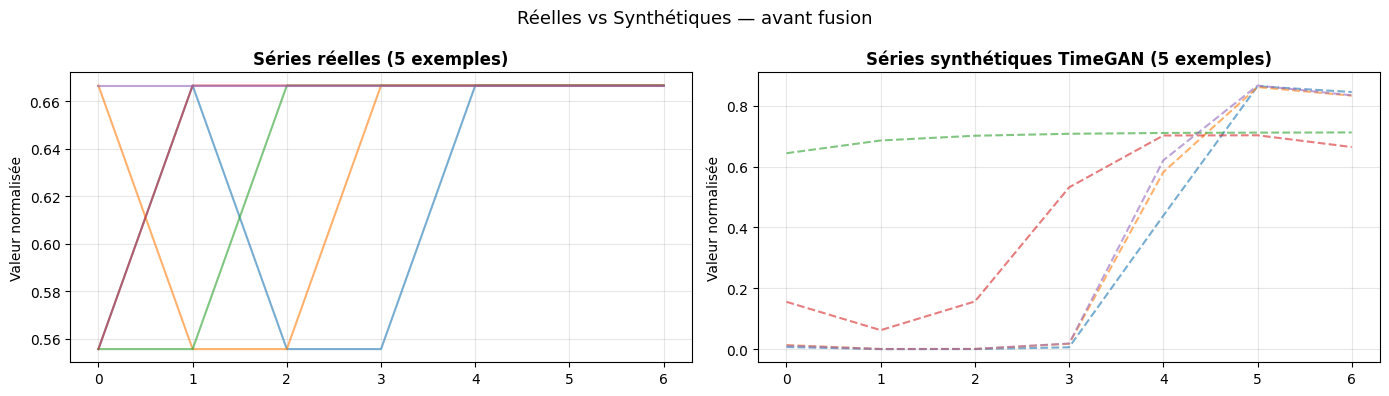

In [7]:
# Générer 100 séries synthétiques avec le TimeGAN
nb_series = 100

with torch.no_grad():
    bruit = torch.randn(nb_series, 32)
    series_synthetiques = generateur(bruit).numpy()

print(f"Séries générées par TimeGAN : {series_synthetiques.shape[0]}")
print(f"Forme : {series_synthetiques.shape}")

# Visualiser quelques séries générées vs réelles
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Réelles
for i in range(5):
    axes[0].plot(X_reel[i].flatten(), alpha=0.6, linewidth=1.5)
axes[0].set_title("Séries réelles (5 exemples)", fontweight='bold')
axes[0].set_ylabel("Valeur normalisée")
axes[0].grid(True, alpha=0.3)

# Synthétiques
for i in range(5):
    axes[1].plot(series_synthetiques[i].flatten(), 
                 alpha=0.6, linewidth=1.5, linestyle='--')
axes[1].set_title("Séries synthétiques TimeGAN (5 exemples)", 
                   fontweight='bold')
axes[1].set_ylabel("Valeur normalisée")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Réelles vs Synthétiques — avant fusion", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# ── Fusion données réelles + synthétiques ─────────────────
X_fusionne = np.concatenate([X_reel, series_synthetiques], axis=0)
y_synthetique = series_synthetiques[:, -1, :]
y_fusionne = np.concatenate([y_reel, y_synthetique], axis=0)

print(f"Séquences réelles    : {X_reel.shape[0]}")
print(f"Séquences synthétiques : {series_synthetiques.shape[0]}")
print(f"Total après fusion   : {X_fusionne.shape[0]}")

# ── Réentraîner le LSTM sur le dataset enrichi ────────────
X_tensor = torch.FloatTensor(X_fusionne)
y_tensor = torch.FloatTensor(y_fusionne)

lstm_enrichi = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_enrichi.parameters(), lr=0.01)

epochs = 200
pertes = []

for epoch in range(epochs):
    lstm_enrichi.train()
    optimizer.zero_grad()
    output = lstm_enrichi(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()
    pertes.append(loss.item())
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/200 — Perte : {loss.item():.6f}")

print("\nEntraînement terminé !")

Séquences réelles    : 173
Séquences synthétiques : 100
Total après fusion   : 273
Epoch 50/200 — Perte : 0.003889
Epoch 100/200 — Perte : 0.001762
Epoch 150/200 — Perte : 0.001649
Epoch 200/200 — Perte : 0.001608

Entraînement terminé !


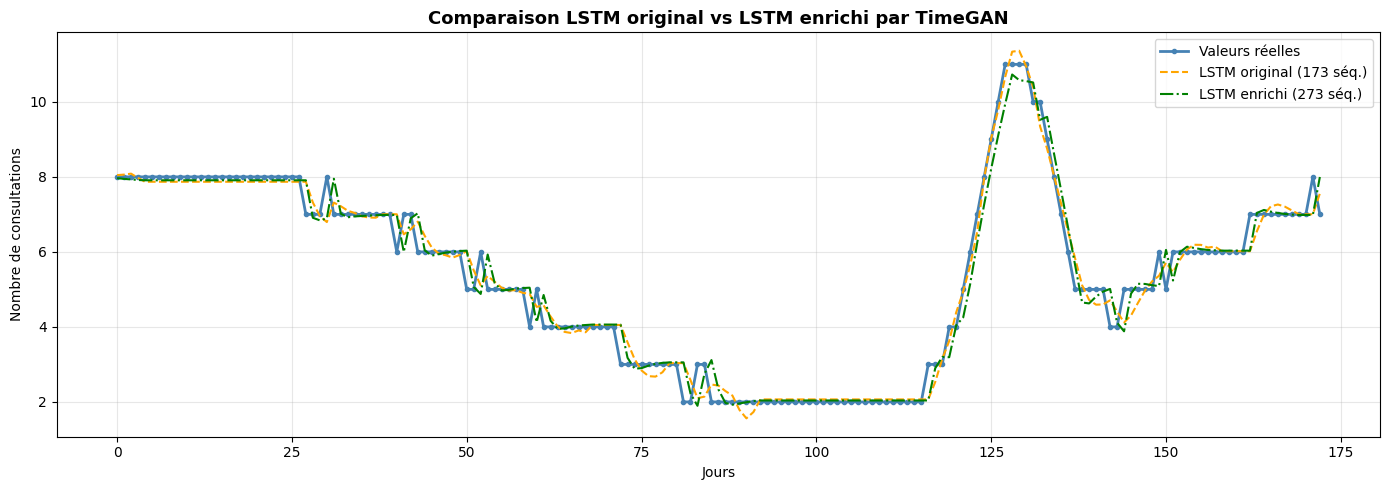

MAE LSTM original : 0.261
MAE LSTM enrichi  : 0.268
Amélioration      : -2.6%


In [9]:
# ── Prédictions LSTM original vs LSTM enrichi ─────────────
X_reel_tensor = torch.FloatTensor(X_reel)

lstm_model.eval()
lstm_enrichi.eval()

with torch.no_grad():
    pred_original = lstm_model(X_reel_tensor).numpy()
    pred_enrichi  = lstm_enrichi(X_reel_tensor).numpy()

# Dénormaliser
pred_original_reel = scaler_lstm.inverse_transform(pred_original)
pred_enrichi_reel  = scaler_lstm.inverse_transform(pred_enrichi)
valeurs_reelles    = scaler_lstm.inverse_transform(y_reel)

# Visualiser
plt.figure(figsize=(14, 5))
plt.plot(valeurs_reelles, label='Valeurs réelles',
         color='steelblue', linewidth=2, marker='o', markersize=3)
plt.plot(pred_original_reel, label='LSTM original (173 séq.)',
         color='orange', linewidth=1.5, linestyle='--')
plt.plot(pred_enrichi_reel, label='LSTM enrichi (273 séq.)',
         color='green', linewidth=1.5, linestyle='-.')

plt.title('Comparaison LSTM original vs LSTM enrichi par TimeGAN',
          fontsize=13, fontweight='bold')
plt.xlabel('Jours')
plt.ylabel('Nombre de consultations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calcul erreur
from sklearn.metrics import mean_absolute_error
mae_original = mean_absolute_error(valeurs_reelles, pred_original_reel)
mae_enrichi  = mean_absolute_error(valeurs_reelles, pred_enrichi_reel)
print(f"MAE LSTM original : {mae_original:.3f}")
print(f"MAE LSTM enrichi  : {mae_enrichi:.3f}")
print(f"Amélioration      : {((mae_original - mae_enrichi)/mae_original*100):.1f}%")

In [10]:
torch.save(lstm_enrichi.state_dict(),
           'models/lstm_enrichi_timegan.pth')
print("LSTM enrichi sauvegardé !")

LSTM enrichi sauvegardé !


In [11]:
# ── Résumé du pipeline complet ────────────────────────────

print("=" * 55)
print("  PIPELINE COMPLET — SSMI")
print("=" * 55)

print("\n ÉTAPE 1 — Données réelles")
print(f"   Jours extraits       : {len(df)}")
print(f"   Séquences créées     : {X_reel.shape[0]}")

print("\n ÉTAPE 2 — TimeGAN")
print(f"   Séries générées      : {nb_series}")
print(f"   Dataset total        : {X_fusionne.shape[0]} séquences")

print("\n ÉTAPE 3 — LSTM original")
print(f"   Entraîné sur         : {X_reel.shape[0]} séquences")
print(f"   MAE                  : {mae_original:.3f}")

print("\n ÉTAPE 4 — LSTM enrichi (TimeGAN + Réel)")
print(f"   Entraîné sur         : {X_fusionne.shape[0]} séquences")
print(f"   MAE                  : {mae_enrichi:.3f}")

print("\n LIMITE IDENTIFIÉE")
print("   Données synthétiques trop différentes")
print("   des vraies distributions médicales")
print("   → Solution : données MOVER (stage IRIT)")

print("\n" + "=" * 55)
print("  PIPELINE TERMINÉ")
print("=" * 55)

  PIPELINE COMPLET — SSMI

 ÉTAPE 1 — Données réelles
   Jours extraits       : 180
   Séquences créées     : 173

 ÉTAPE 2 — TimeGAN
   Séries générées      : 100
   Dataset total        : 273 séquences

 ÉTAPE 3 — LSTM original
   Entraîné sur         : 173 séquences
   MAE                  : 0.261

 ÉTAPE 4 — LSTM enrichi (TimeGAN + Réel)
   Entraîné sur         : 273 séquences
   MAE                  : 0.268

 LIMITE IDENTIFIÉE
   Données synthétiques trop différentes
   des vraies distributions médicales
   → Solution : données MOVER (stage IRIT)

  PIPELINE TERMINÉ


In [13]:
# ── Définition Discriminateur ─────────────────────────────
class Discriminateur(nn.Module):
    def __init__(self, hidden_size=64, seq_len=7):
        super(Discriminateur, self).__init__()
        self.lstm = nn.LSTM(1, hidden_size,
                           num_layers=2, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)
# ── TimeGAN entraîné uniquement sur le Paludisme ──────────

# 1. Séquences Paludisme uniquement
scaler_pal = MinMaxScaler()
valeurs_pal = df['nombre'].values.reshape(-1, 1)
valeurs_pal_norm = scaler_pal.fit_transform(valeurs_pal)

sequences_pal = []
for i in range(len(valeurs_pal_norm) - 7):
    sequences_pal.append(valeurs_pal_norm[i:i+7])
sequences_pal = np.array(sequences_pal)

X_pal_tensor = torch.FloatTensor(sequences_pal)
print(f"Séquences Paludisme : {sequences_pal.shape[0]}")

# 2. TimeGAN Paludisme
generateur_pal = Generateur(bruit_dim=32, hidden_size=64, seq_len=7)
discriminateur_pal = Discriminateur(hidden_size=64, seq_len=7)

optimizer_G_pal = torch.optim.Adam(generateur_pal.parameters(), lr=0.0001)
optimizer_D_pal = torch.optim.Adam(discriminateur_pal.parameters(), lr=0.0001)
criterion_bce = nn.BCELoss()

for epoch in range(1000):
    generateur_pal.train()
    discriminateur_pal.train()

    idx = np.random.randint(0, len(X_pal_tensor), 16)
    vraies = X_pal_tensor[idx]
    vrais_labels = torch.ones(16, 1)
    faux_labels  = torch.zeros(16, 1)

    bruit  = torch.randn(16, 32)
    fausses = generateur_pal(bruit)

    perte_D = criterion_bce(discriminateur_pal(vraies), vrais_labels) + \
              criterion_bce(discriminateur_pal(fausses.detach()), faux_labels)
    optimizer_D_pal.zero_grad()
    perte_D.backward()
    optimizer_D_pal.step()

    for _ in range(2):
        bruit   = torch.randn(16, 32)
        fausses = generateur_pal(bruit)
        perte_G = criterion_bce(discriminateur_pal(fausses), vrais_labels)
        optimizer_G_pal.zero_grad()
        perte_G.backward()
        optimizer_G_pal.step()

    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}/1000 — G: {perte_G.item():.4f} · D: {perte_D.item():.4f}")

print("\nTimeGAN Paludisme entraîné !")

Séquences Paludisme : 173
Epoch 200/1000 — G: 0.6960 · D: 1.3856
Epoch 400/1000 — G: 0.6925 · D: 1.3880
Epoch 600/1000 — G: 0.7677 · D: 1.3893
Epoch 800/1000 — G: 0.7697 · D: 1.2584
Epoch 1000/1000 — G: 0.7619 · D: 1.3919

TimeGAN Paludisme entraîné !


Réelles    : 173 séquences
Synthétiques : 100 séquences
Total      : 273 séquences
Epoch 50/200 — Perte : 0.005831
Epoch 100/200 — Perte : 0.001798
Epoch 150/200 — Perte : 0.001633
Epoch 200/200 — Perte : 0.001568

Entraînement terminé !


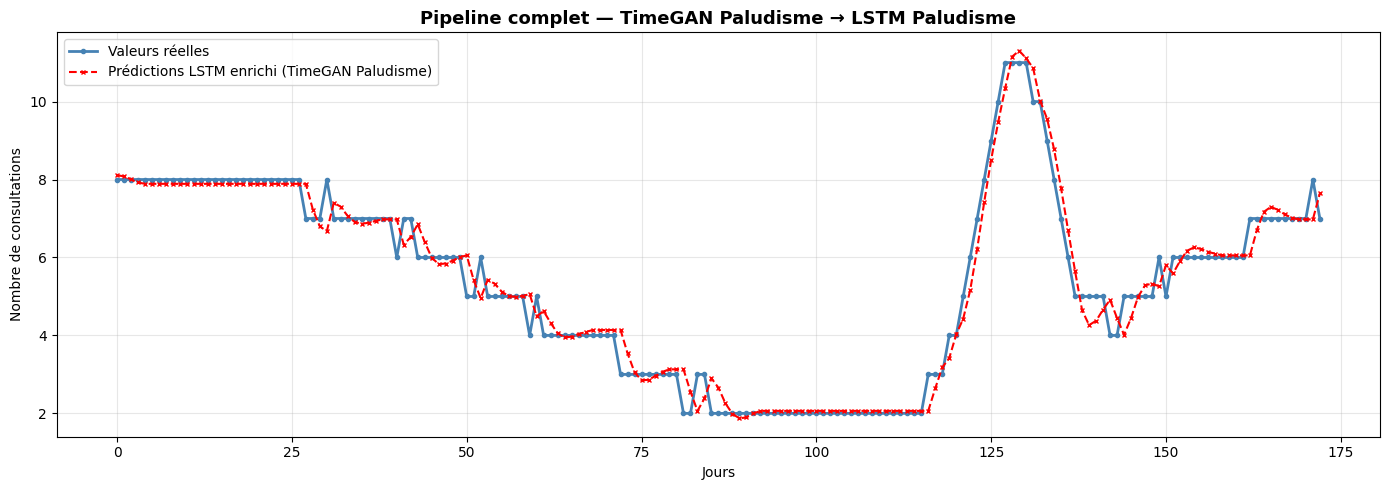

In [14]:
# ── Générer 100 séries Paludisme avec TimeGAN ─────────────
generateur_pal.eval()
with torch.no_grad():
    bruit = torch.randn(100, 32)
    series_pal_synthetiques = generateur_pal(bruit).numpy()

# ── Fusionner ─────────────────────────────────────────────
X_fusionne_pal = np.concatenate([X_reel, series_pal_synthetiques], axis=0)
y_synthetique_pal = series_pal_synthetiques[:, -1, :]
y_fusionne_pal = np.concatenate([y_reel, y_synthetique_pal], axis=0)

print(f"Réelles    : {X_reel.shape[0]} séquences")
print(f"Synthétiques : {series_pal_synthetiques.shape[0]} séquences")
print(f"Total      : {X_fusionne_pal.shape[0]} séquences")

# ── LSTM entraîné sur données enrichies Paludisme ─────────
lstm_pal = LSTMModel()
optimizer = torch.optim.Adam(lstm_pal.parameters(), lr=0.01)
criterion = nn.MSELoss()

X_tensor = torch.FloatTensor(X_fusionne_pal)
y_tensor = torch.FloatTensor(y_fusionne_pal)

for epoch in range(200):
    lstm_pal.train()
    optimizer.zero_grad()
    output = lstm_pal(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/200 — Perte : {loss.item():.6f}")

print("\nEntraînement terminé !")

# ── Visualiser les prédictions ────────────────────────────
lstm_pal.eval()
X_reel_tensor = torch.FloatTensor(X_reel)

with torch.no_grad():
    predictions = scaler_pal.inverse_transform(
        lstm_pal(X_reel_tensor).numpy())
valeurs_reelles = scaler_pal.inverse_transform(y_reel)

plt.figure(figsize=(14, 5))
plt.plot(valeurs_reelles, label='Valeurs réelles',
         color='steelblue', linewidth=2, marker='o', markersize=3)
plt.plot(predictions, label='Prédictions LSTM enrichi (TimeGAN Paludisme)',
         color='red', linewidth=1.5, linestyle='--', marker='x', markersize=3)
plt.title('Pipeline complet — TimeGAN Paludisme → LSTM Paludisme',
          fontsize=13, fontweight='bold')
plt.xlabel('Jours')
plt.ylabel('Nombre de consultations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

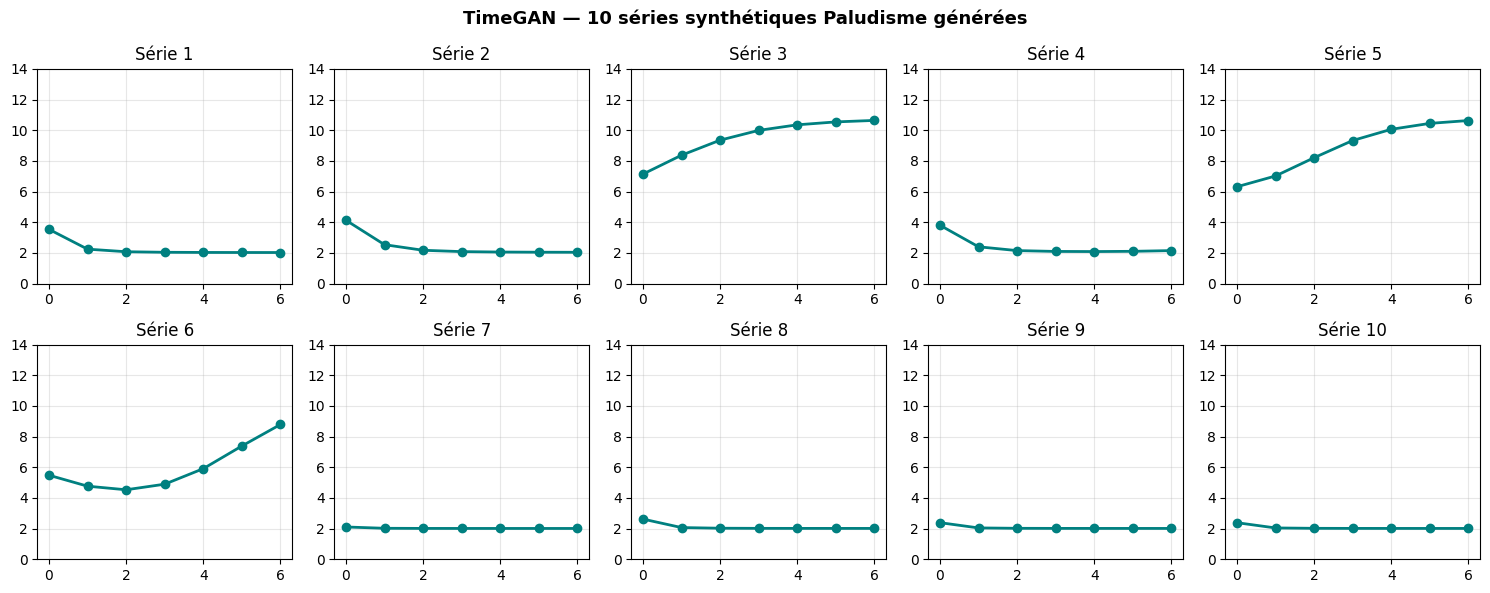

Epoch 50/200 — Perte : 0.007070
Epoch 100/200 — Perte : 0.002141
Epoch 150/200 — Perte : 0.002003
Epoch 200/200 — Perte : 0.001863


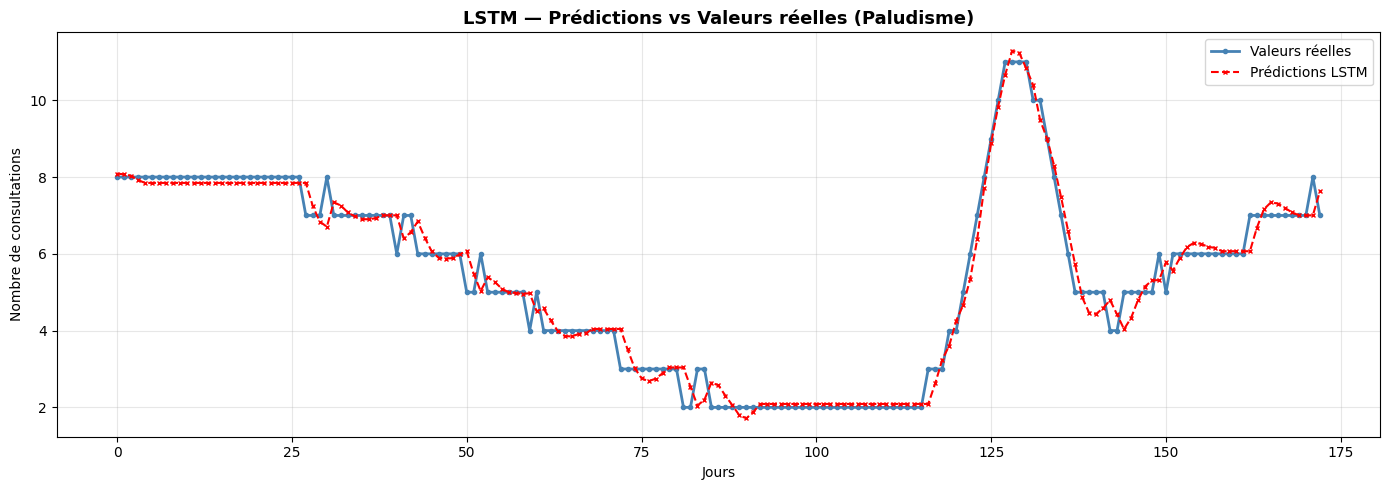

In [15]:
# ── GRAPHIQUE 1 : TimeGAN — Séries synthétiques Paludisme ─
generateur_pal.eval()
with torch.no_grad():
    bruit = torch.randn(10, 32)
    series_synthetiques = generateur_pal(bruit).numpy()

# Dénormaliser
series_denorm = []
for serie in series_synthetiques:
    s = scaler_pal.inverse_transform(serie)
    series_denorm.append(s.flatten())

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i, serie in enumerate(series_denorm):
    axes[i].plot(serie, marker='o', color='teal', linewidth=2)
    axes[i].set_title(f'Série {i+1}')
    axes[i].set_ylim(0, 14)
    axes[i].grid(True, alpha=0.3)
plt.suptitle('TimeGAN — 10 séries synthétiques Paludisme générées',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── GRAPHIQUE 2 : LSTM — Prédictions vs Valeurs réelles ───
X_fusionne_pal = np.concatenate([X_reel, series_synthetiques], axis=0)
y_synthetique_pal = series_synthetiques[:, -1, :]
y_fusionne_pal = np.concatenate([y_reel, y_synthetique_pal], axis=0)

lstm_pal = LSTMModel()
optimizer = torch.optim.Adam(lstm_pal.parameters(), lr=0.01)
criterion = nn.MSELoss()

X_tensor = torch.FloatTensor(X_fusionne_pal)
y_tensor = torch.FloatTensor(y_fusionne_pal)

for epoch in range(200):
    lstm_pal.train()
    optimizer.zero_grad()
    output = lstm_pal(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/200 — Perte : {loss.item():.6f}")

lstm_pal.eval()
X_reel_tensor = torch.FloatTensor(X_reel)
with torch.no_grad():
    predictions = scaler_pal.inverse_transform(
        lstm_pal(X_reel_tensor).numpy())
valeurs_reelles = scaler_pal.inverse_transform(y_reel)

plt.figure(figsize=(14, 5))
plt.plot(valeurs_reelles, label='Valeurs réelles',
         color='steelblue', linewidth=2, marker='o', markersize=3)
plt.plot(predictions, label='Prédictions LSTM',
         color='red', linewidth=1.5, linestyle='--', marker='x', markersize=3)
plt.title('LSTM — Prédictions vs Valeurs réelles (Paludisme)',
          fontsize=13, fontweight='bold')
plt.xlabel('Jours')
plt.ylabel('Nombre de consultations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ── Métriques MMD et DTW ───────────────────────────────────

def calculer_mmd(X_reel, X_genere, sigma=1.0):
    def rbf_kernel(X, Y, sigma):
        XX = np.sum(X**2, axis=1, keepdims=True)
        YY = np.sum(Y**2, axis=1, keepdims=True)
        XY = np.dot(X, Y.T)
        distances = XX + YY.T - 2*XY
        return np.exp(-distances / (2 * sigma**2))
    
    K_XX = rbf_kernel(X_reel, X_reel, sigma)
    K_YY = rbf_kernel(X_genere, X_genere, sigma)
    K_XY = rbf_kernel(X_reel, X_genere, sigma)
    return K_XX.mean() + K_YY.mean() - 2*K_XY.mean()

def calculer_dtw(serie1, serie2):
    n, m = len(serie1), len(serie2)
    dtw_matrix = np.full((n+1, m+1), np.inf)
    dtw_matrix[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(serie1[i-1] - serie2[j-1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )
    return dtw_matrix[n, m]

# Prendre 10 séries réelles et 10 séries synthétiques
vraies = sequences_pal[:10].reshape(10, 7)
synthetiques = series_pal_synthetiques[:10].reshape(10, 7)

# Calculer MMD
mmd = calculer_mmd(vraies, synthetiques)

# Calculer DTW moyen
dtw_scores = []
for i in range(10):
    score = calculer_dtw(vraies[i], synthetiques[i])
    dtw_scores.append(score)
dtw_moyen = np.mean(dtw_scores)

print("="*40)
print("MÉTRIQUES — TimeGAN Paludisme")
print("="*40)
print(f"MMD  : {mmd:.4f}")
print(f"DTW  : {dtw_moyen:.4f}")
print("="*40)
print(f"\nInterprétation MMD : ", end="")
if mmd < 0.05:
    print("Excellent")
elif mmd < 0.1:
    print("Bon")
elif mmd < 0.5:
    print("Acceptable")
else:
    print("A améliorer")

print(f"Interprétation DTW : ", end="")
if dtw_moyen < 0.5:
    print("Excellent")
elif dtw_moyen < 1.0:
    print("Bon")
elif dtw_moyen < 2.0:
    print("Acceptable")
else:
    print("A améliorer")

MÉTRIQUES — TimeGAN Paludisme
MMD  : 0.2788
DTW  : 2.2851

Interprétation MMD : Acceptable
Interprétation DTW : A améliorer
